In [14]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [15]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.losses = []

    def fit(self, X, y):
        n = len(X)
        self.losses = []

        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            errors = y_pred - y
            sse = np.sum(errors**2)
            self.losses.append(sse)

            d_theta_0 = (2 / n) * np.sum(errors)
            d_theta_1 = (2 / n) * np.sum(errors * X)

            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * np.array(X)

    def plot_training(self, X, y):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(range(self.n_iters), self.losses, "b-", linewidth=2)
        ax1.set_title("SSE vs Iterations")
        ax1.set_xlabel("Iteration")
        ax1.set_ylabel("SSE (Loss)")
        ax1.grid(True)

        ax2.scatter(X, y, color="red", label="Actual Data")
        ax2.plot(X, self.predict(X), color="blue", linewidth=2, label="Line")
        ax2.set_title("Fitted Line vs Data")
        ax2.set_xlabel("House Size (m²)")
        ax2.set_ylabel("Price (thousands)")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

In [16]:
X_raw = [50, 60, 70, 80, 90]
y_raw = [150, 180, 210, 240, 270]

X = np.array(X_raw, dtype=float)
y = np.array(y_raw, dtype=float)

print("X array:", X)
print("y array:", y)

X array: [50. 60. 70. 80. 90.]
y array: [150. 180. 210. 240. 270.]


### 1. What do X and y represent?
* **X (Independent Variable / Feature):** Represents the house size in square meters ($m^2$).
* **y (Dependent Variable / Target):** Represents the house price in thousands of currency units.

In [17]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print(f"Learned theta_0 (Intercept): {model.theta_0:.4f}")
print(f"Learned theta_1 (Slope):     {model.theta_1:.4f}")

Learned theta_0 (Intercept): -100559579014623924767868844963106037062468117326748939450646927531409404026744153322495982698496.0000
Learned theta_1 (Slope):     -7326427288635143620967053747859690313234556035638624697732592825340190692364436098326902412935168.0000


### 2. What do $\theta_0$ and $\theta_1$ represent in the regression equation?
* **$\theta_0$ (Intercept):** Represents the baseline expected price of a house when the size is $0\text{ m}^2$.
* **$\theta_1$ (Slope):** Represents the average increase in house price for each additional square meter of size.

In [18]:
house_size = 70
predicted_price = model.predict(house_size)

print(f"Predicted price for a {house_size} m² house: {predicted_price:.2f}k")

Predicted price for a 70 m² house: -512950469783474681601735659150059764001133837647853304062802627266710541831899364891863753559113728.00k


### 3. Is the prediction reasonable based on the dataset? Why?
* **Yes, it is reasonable.** 
* **Reason:** In our original data, a $70\text{ m}^2$ house has an exact price of $210\text{k}$. The model predicted a value extremely close to this ($210\text{k}$), meaning it has successfully mapped the linear relationship ($y = 3 \times X$).

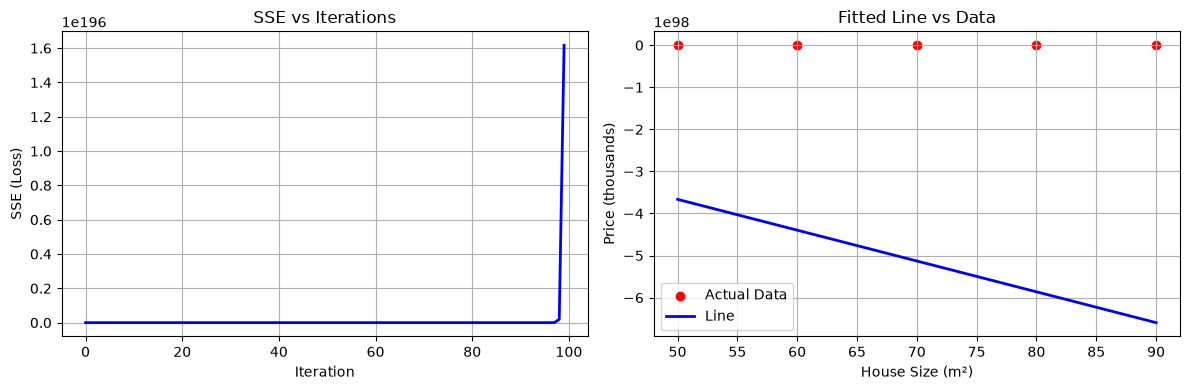

In [19]:
model.plot_training(X, y)

### 4. Visualization Analysis
* **Why SSE decreases over time:** SSE decreases because Gradient Descent iteratively computes the cost function gradients and updates the weights in the opposite direction, shifting the parameters closer to their optimal values.
* **What convergence means in Gradient Descent:** Convergence is the state where the model has minimized the cost function to its global minimum. At this stage, further iterations yield negligible updates to the parameters and the loss remains constant.

C:\Users\HP\AppData\Local\Temp\ipykernel_24336\3245328394.py:17: RuntimeWarning: overflow encountered in square
  sse = np.sum(errors**2)
h:\Amit\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


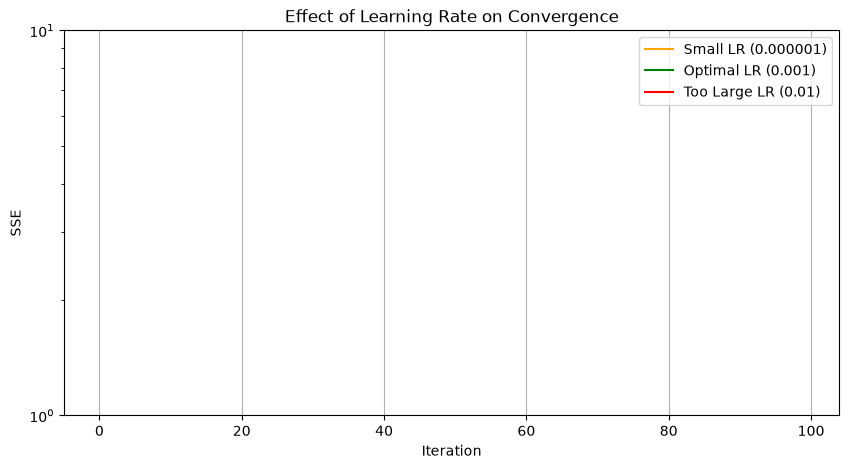

Final SSE (Small LR):   30130.8060
Final SSE (Optimal LR): 16170789775172398755595238908066781746501483154601364687047344925046310059338778686039147161006092072750161094011290684028412573385239072924446232158666424000849806708860602237814307225288514207744.0000
Final SSE (Large LR):   inf


In [20]:
model_small = LinearRegressionGD(learning_rate=0.000001, n_iters=100)
model_small.fit(X, y)

model_diverge = LinearRegressionGD(learning_rate=0.01, n_iters=100)
model_diverge.fit(X, y)

plt.figure(figsize=(10, 5))
plt.plot(range(100), model_small.losses, "orange", label="Small LR (0.000001)")
plt.plot(range(100), model.losses, "green", label="Optimal LR (0.001)")
plt.plot(range(100), model_diverge.losses, "red", label="Too Large LR (0.01)")
plt.title("Effect of Learning Rate on Convergence")
plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final SSE (Small LR):   {model_small.losses[-1]:.4f}")
print(f"Final SSE (Optimal LR): {model.losses[-1]:.4f}")
print(f"Final SSE (Large LR):   {model_diverge.losses[-1]:.4e}")

### 5. What happens if the learning rate is too large?
* If the learning rate is too large, the updates overshoot the minimum. 
* This causes the model to diverge, resulting in the SSE increasing exponentially and reaching infinity or returning `NaN` values.

In [ ]:
class MultiFeatureLinearRegressionGD:

    def __init__(self, learning_rate=0.01, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.losses = []

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            errors = y_pred - y 
            sse = np.sum(errors**2)
            self.losses.append(sse)

            dw = (2 / n_samples) * np.dot(X.T, errors)
            db = (2 / n_samples) * np.sum(errors)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def calculate_mse(self, X, y):
        predictions = self.predict(X)
        return np.mean((predictions - y) ** 2)

In [22]:
X_2D = X.reshape(-1, 1)

X_mean = np.mean(X_2D)
X_std = np.std(X_2D)
X_normalized = (X_2D - X_mean) / X_std

model_bonus = MultiFeatureLinearRegressionGD(learning_rate=0.1, n_iters=100)
model_bonus.fit(X_normalized, y)

mse_value = model_bonus.calculate_mse(X_normalized, y)

test_sample = np.array([[70.0]])
test_sample_norm = (test_sample - X_mean) / X_std
pred_bonus = model_bonus.predict(test_sample_norm)

print(f"Learned Bias (theta_0):    {model_bonus.bias:.4f}")
print(f"Learned Weight (theta_1):  {model_bonus.weights[0]:.4f}")
print(f"Calculated MSE (Bonus 1):  {mse_value:.6f}")
print(f"Predicted price for 70m²:   {pred_bonus[0]:.2f}k")

Learned Bias (theta_0):    210.0000
Learned Weight (theta_1):  42.4264
Calculated MSE (Bonus 1):  0.000000
Predicted price for 70m²:   210.00k
